In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")

df = pd.read_csv("cleaned_house_data.csv")
os.makedirs("plots", exist_ok=True)  # folder where exported images will be saved

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


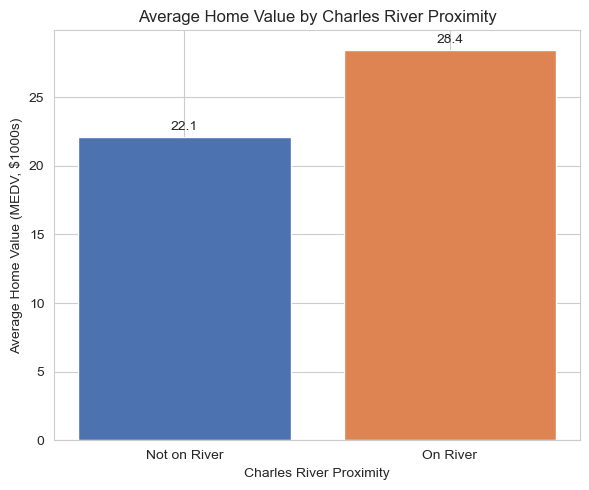

In [6]:
river_avg = df.groupby("CHAS")["MEDV"].mean()

plt.figure(figsize=(6, 5))
plt.bar(["Not on River", "On River"], river_avg.values, color=["#4C72B0", "#DD8452"])
plt.title("Average Home Value by Charles River Proximity")
plt.xlabel("Charles River Proximity")
plt.ylabel("Average Home Value (MEDV, $1000s)")

for i, v in enumerate(river_avg.values):
    plt.text(i, v + 0.5, f"{v:.1f}", ha="center")

plt.tight_layout()
plt.savefig("plots/bar_river_avg_price.png", dpi=150)
plt.show()

C:\Users\FBDA22-007\AppData\Local\Temp\ipykernel_13264\1062455066.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_trend = df.groupby("AGE_BIN")["MEDV"].mean()


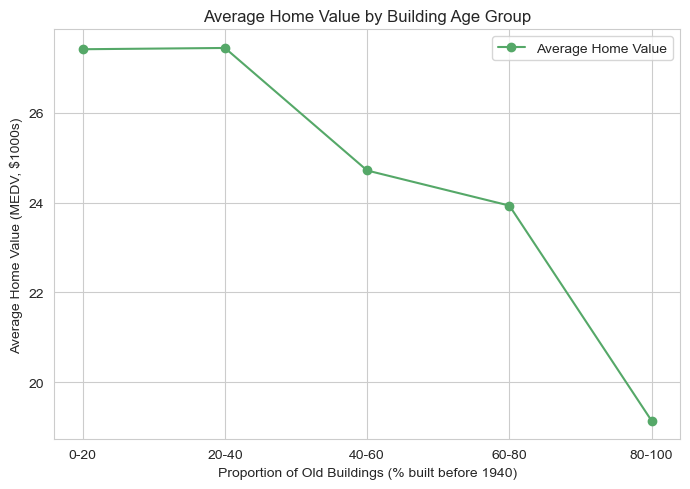

In [7]:
df["AGE_BIN"] = pd.cut(df["AGE"], bins=[0, 20, 40, 60, 80, 100],
                        labels=["0-20", "20-40", "40-60", "60-80", "80-100"])
age_trend = df.groupby("AGE_BIN")["MEDV"].mean()

plt.figure(figsize=(7, 5))
plt.plot(age_trend.index.astype(str), age_trend.values, marker="o",
         color="#55A868", label="Average Home Value")
plt.title("Average Home Value by Building Age Group")
plt.xlabel("Proportion of Old Buildings (% built before 1940)")
plt.ylabel("Average Home Value (MEDV, $1000s)")
plt.legend()
plt.tight_layout()
plt.savefig("plots/line_age_trend.png", dpi=150)
plt.show()

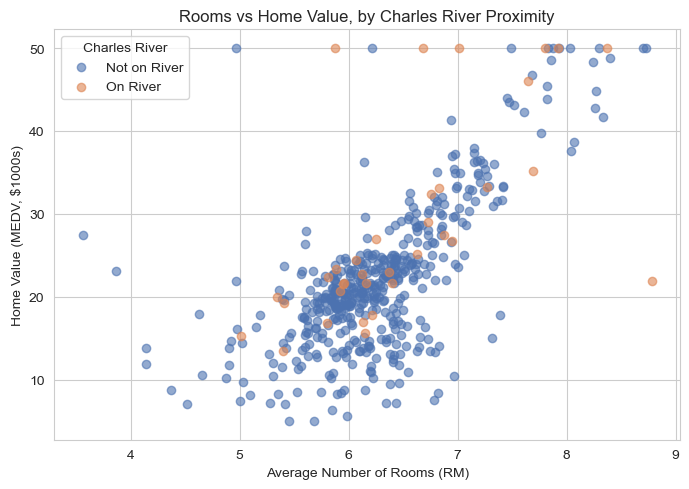

In [8]:
plt.figure(figsize=(7, 5))
for chas_val, label, color in [(0, "Not on River", "#4C72B0"), (1, "On River", "#DD8452")]:
    subset = df[df["CHAS"] == chas_val]
    plt.scatter(subset["RM"], subset["MEDV"], alpha=0.6, label=label, color=color)

plt.title("Rooms vs Home Value, by Charles River Proximity")
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Home Value (MEDV, $1000s)")
plt.legend(title="Charles River")
plt.tight_layout()
plt.savefig("plots/scatter_rm_vs_medv.png", dpi=150)
plt.show()